In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
df = pd.read_csv("store_sales(1).csv")

print(df.head())
print(df.shape)



         date  store   sales  promo  holiday
0  2022-01-01      1  184.78      0        0
1  2022-01-02      1  192.62      0        0
2  2022-01-03      1  212.68      0        0
3  2022-01-04      1  249.58      1        0
4  2022-01-05      1  223.50      0        0
(7300, 5)


In [16]:
print(df.isnull().sum())

df = df.drop_duplicates()

df['date'] = pd.to_datetime(df['date'])

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64


In [17]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

In [18]:
X = df[['store',
        'promo',
        'holiday',
        'year',
        'month',
        'day',
        'dayofweek',
        'weekofyear']]

y = df['sales']

In [19]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [20]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test,y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test,y_pred)
)

r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 13.909709041095894
RMSE : 15.814776731151612
R2 : 0.6940186441145636


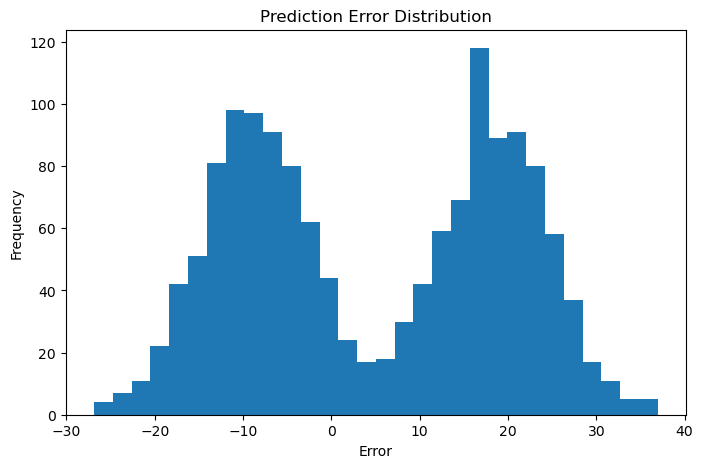

In [22]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors,bins=30)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

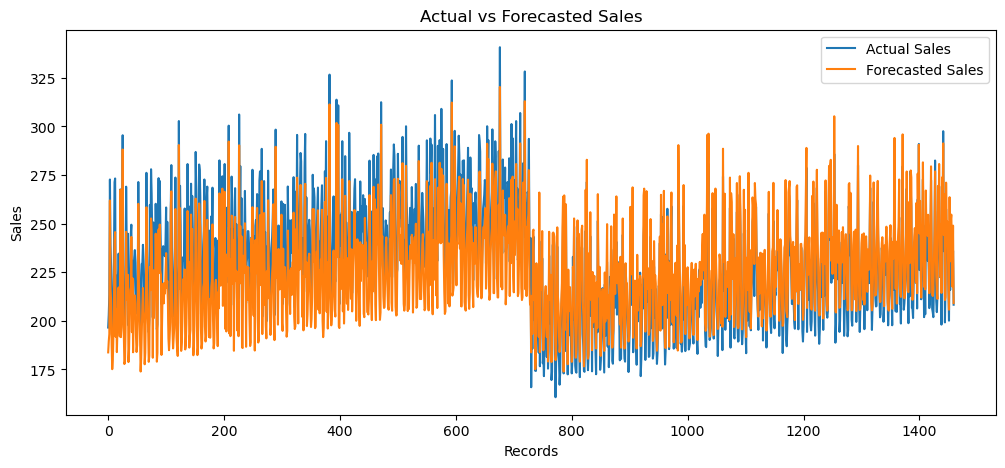

In [23]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_pred,
    label="Forecasted Sales"
)

plt.title(
    "Actual vs Forecasted Sales"
)

plt.xlabel("Records")

plt.ylabel("Sales")

plt.legend()

plt.show()